In [ ]:
import numpy as np
import pandas as pd
import time


In [ ]:
import kagglehub
path = kagglehub.dataset_download("akram24/social-network-ads")

Using Colab cache for faster access to the 'social-network-ads' dataset.


In [ ]:
import os
file_path = os.path.join(path, 'Social_Network_Ads.csv')
df = pd.read_csv(file_path)
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Select relevant features: Gender, Age, EstimatedSalary
X = df[['Gender', 'Age', 'EstimatedSalary']].copy()

# Encode 'Gender' to numerical (e.g., 0 for Female, 1 for Male)
le = LabelEncoder()
X.loc[:, 'Gender'] = le.fit_transform(X['Gender'])

# Select target variable: Purchased
y = df['Purchased']

In [ ]:
X

,Gender,Age,EstimatedSalary
0,1,19,19000
1,1,35,20000
2,0,26,43000
3,0,27,57000
4,1,19,76000
...,...,...,...
395,0,46,41000
396,1,51,23000
397,0,50,20000
398,1,36,33000


In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X = sc.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [ ]:
X_train.shape

(320, 3)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [ ]:
model = Sequential()
model.add(Dense(10,activation='relu',input_dim=3)) # Changed input_dim from 2 to 3
model.add(Dense(10,activation ='relu'))
model.add(Dense(1,activation = 'sigmoid'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_26 (Dense)                │ (None, 10)             │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161 (644.00 B)

 Trainable params: 161 (644.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
len(X_train)

320

In [ ]:
model.compile(optimizer='adam' ,loss = 'binary_crossentropy' , metrics = ['accuracy'])
start = time.time()
history = model.fit(X_train, y_train.values, epochs = 10, batch_size = 320)
print(time.time()-start)
## here batch size is 320  means its batch GD bcz it has 320 rows thats why batch size is 320

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.2906 - loss: 0.7950
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.2906 - loss: 0.7906
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.2875 - loss: 0.7862
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.2844 - loss: 0.7820
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.2875 - loss: 0.7777
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.2875 - loss: 0.7736
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.2844 - loss: 0.7695
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.2875 - loss: 0.7655
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.2844 - loss: 0.7615
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.2844 - loss: 0.7576
2.5486793518066406


In [ ]:
## batch size is n(num of rows) = batch GD
## batch size is 1 = stochastics


In [ ]:
model.compile(optimizer='adam' ,loss = 'binary_crossentropy' , metrics = ['accuracy'])
start = time.time()
history = model.fit(X_train, y_train.values, epochs = 10, batch_size = 1)
print(time.time()-start)

Epoch 1/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6469 - loss: 0.5998
Epoch 2/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8156 - loss: 0.4328
Epoch 3/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8656 - loss: 0.3485
Epoch 4/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8656 - loss: 0.3018
Epoch 5/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8750 - loss: 0.2846
Epoch 6/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8875 - loss: 0.2752
Epoch 7/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8844 - loss: 0.2693
Epoch 8/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9062 - loss: 0.2595
Epoch 9/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8938 - loss: 0.2569
Epoch 10/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9031 - loss: 0.2518
21.630777597427368


In [ ]:
## from this be can conclude that batch GD is faster(on the perspective of time)

In [ ]:
## if for same num of epochs we run batch as well as stochastic which gives results first here ans is stochastic


In [ ]:
model = Sequential()
model.add(Dense(10,activation='relu',input_dim=3)) # Changed input_dim from 2 to 3
model.add(Dense(10,activation ='relu'))
model.add(Dense(1,activation = 'sigmoid'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_29 (Dense)                │ (None, 10)             │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161 (644.00 B)

 Trainable params: 161 (644.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
X_scaled = sc.fit_transform(X)

In [ ]:
X_scaled.shape

(400, 3)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()


In [ ]:
model.compile(optimizer='adam' ,loss = 'binary_crossentropy' , metrics = ['accuracy'])
start = time.time()
history = model.fit(X_scaled, y.values, epochs = 10, batch_size = 400 ,validation_split=0.2)
print(time.time()-start)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.4969 - loss: 0.7511 - val_accuracy: 0.2375 - val_loss: 0.8461
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.5031 - loss: 0.7471 - val_accuracy: 0.2375 - val_loss: 0.8414
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.5125 - loss: 0.7431 - val_accuracy: 0.2500 - val_loss: 0.8368
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.5219 - loss: 0.7392 - val_accuracy: 0.2500 - val_loss: 0.8322
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.5281 - loss: 0.7353 - val_accuracy: 0.2500 - val_loss: 0.8276
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.5406 - loss: 0.7314 - val_accuracy: 0.2500 - val_loss: 0.8232
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.5562 - loss: 0.7275 - val_accuracy: 0.2500 - val_loss: 0.8187
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.5813 - loss: 0.7237 - val_accuracy: 0.2625 - val_loss: 0.8144
Ep

In [ ]:
model.compile(optimizer='adam' ,loss = 'binary_crossentropy' , metrics = ['accuracy'])
start = time.time()
history = model.fit(X_scaled, y.values, epochs = 10, batch_size = 1 ,validation_split=0.2)
print(time.time()-start)

Epoch 1/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7844 - loss: 0.5592 - val_accuracy: 0.6875 - val_loss: 0.6071
Epoch 2/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8438 - loss: 0.3891 - val_accuracy: 0.7875 - val_loss: 0.5119
Epoch 3/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8562 - loss: 0.3406 - val_accuracy: 0.7625 - val_loss: 0.4777
Epoch 4/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8500 - loss: 0.3190 - val_accuracy: 0.7875 - val_loss: 0.4409
Epoch 5/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8531 - loss: 0.3071 - val_accuracy: 0.7750 - val_loss: 0.4247
Epoch 6/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8469 - loss: 0.2959 - val_accuracy: 0.9000 - val_loss: 0.3878
Epoch 7/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8656 - loss: 0.2861 - val_accuracy: 0.9125 - val_loss: 0.3725
Epoch 8/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8625 - loss: 0.2771 - val_accuracy: 0.

## to understand graphs

In [ ]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
start = time.time()
history = model.fit(X_scaled, y.values, epochs=500, batch_size=1, validation_split=0.2)

Epoch 1/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8844 - loss: 0.2632 - val_accuracy: 0.9500 - val_loss: 0.2957
Epoch 2/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8906 - loss: 0.2582 - val_accuracy: 0.9750 - val_loss: 0.2790
Epoch 3/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9000 - loss: 0.2527 - val_accuracy: 0.9750 - val_loss: 0.2754
Epoch 4/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8906 - loss: 0.2505 - val_accuracy: 0.9500 - val_loss: 0.2877
Epoch 5/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9000 - loss: 0.2488 - val_accuracy: 0.9625 - val_loss: 0.2759
Epoch 6/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8969 - loss: 0.2455 - val_accuracy: 0.9625 - val_loss: 0.2696
Epoch 7/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8969 - loss: 0.2449 - val_accuracy: 0.9500 - val_loss: 0.2645
Epoch 8/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8938 - loss: 0.2428 - val_accu

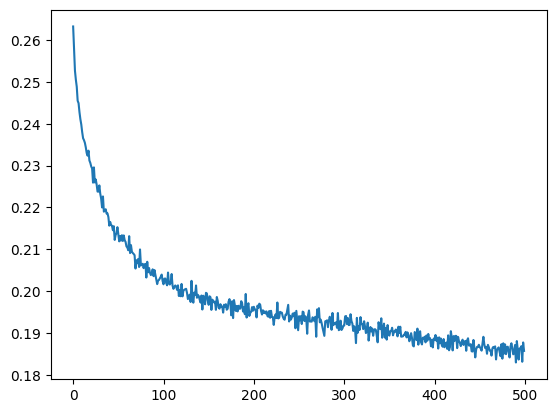

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])

In [ ]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
start = time.time()
history = model.fit(X_scaled, y.values, epochs=500, batch_size=400, validation_split=0.2)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9125 - loss: 0.1762 - val_accuracy: 0.8875 - val_loss: 0.2808
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9125 - loss: 0.1756 - val_accuracy: 0.9000 - val_loss: 0.2740
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9125 - loss: 0.1752 - val_accuracy: 0.9000 - val_loss: 0.2683
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.9094 - loss: 0.1749 - val_accuracy: 0.9000 - val_loss: 0.2636
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.9094 - loss: 0.1749 - val_accuracy: 0.9000 - val_loss: 0.2595
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9125 - loss: 0.1750 - val_accuracy: 0.9125 - val_loss: 0.2565
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.9125 - loss: 0.1750 - val_accuracy: 0.9125 - val_loss: 0.2546
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.9125 - loss: 0.1750 - val_accuracy: 0.9125 - val_loss:

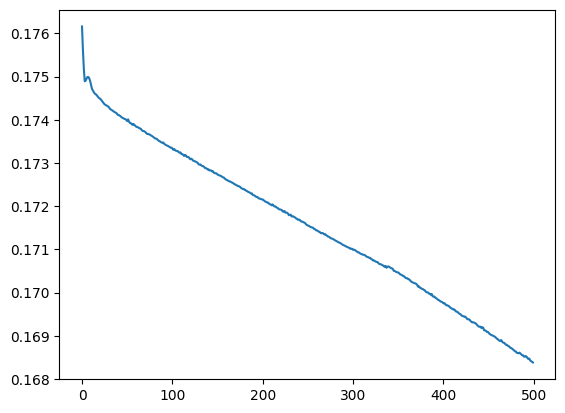

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])